# 🏥 nnU-Net Kidney Stone Segmentation
## Complete Research Pipeline

---

### 📋 What This Notebook Covers

| Category | Items |
|---|---|
| **Segmentation Metrics** | Dice, F1, IoU/Jaccard, Precision, Recall, Sensitivity, Specificity |
| **Boundary Metrics** | Hausdorff Distance 95 (HD95) |
| **Statistical Tests** | Wilcoxon Signed-Rank, One-Sample t-test |
| **Curves & Figures** | ROC/AUC, Convergence Curves, Confusion Matrix, Prediction Overlay |
| **Training Analysis** | Learning Rate Schedule, Convergence Epoch, Training Time per GPU |
| **Tables** | IEEE Results Table, LaTeX-ready Table, Ablation Study |
| **Text** | Auto-generated Methods, Results, Implementation sections |

---



In [1]:
import torch
import gc
import os

# ── GPU Utility Functions (used throughout entire notebook) ──────────────────
def clear_gpu():
    """Clear GPU memory. Call between folds to prevent accumulation."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def gpu_report(label=""):
    """Print GPU memory status."""
    if torch.cuda.is_available():
        alloc  = torch.cuda.memory_allocated(0)  / 1e9
        reserv = torch.cuda.memory_reserved(0)   / 1e9
        total  = torch.cuda.get_device_properties(0).total_memory / 1e9
        free   = total - reserv
        bar    = "█" * int(free / total * 20) + "░" * int((1 - free/total) * 20)
        print(f"  GPU [{label:20s}] Free:{free:.1f}GB / {total:.1f}GB  [{bar}]")

def safe_del(*args):
    """Delete variables and clear GPU — safe memory management."""
    for arg in args:
        try:
            del arg
        except Exception:
            pass
    clear_gpu()

# ── GPU Information ──────────────────────────────────────────────────────────
print("=" * 70)
print("          GPU INFORMATION & MEMORY STATUS")
print("=" * 70)
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  Version  : {torch.version.cuda}")
    print(f"  Devices  : {torch.cuda.device_count()}")
    name   = torch.cuda.get_device_name(0)
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU Name : {name}")
    print(f"  VRAM     : {mem_gb:.1f} GB")
    gpu_report("startup")

    if mem_gb >= 30:
        print("\n  ✅ A100 — Optimal. All features enabled.")
        GPU_TIER = "A100"
    elif mem_gb >= 14:
        print("\n  ✅ V100/T4 — Good. compile=False enabled for safety.")
        GPU_TIER = "V100_T4"
    else:
        print(f"\n  ⚠  Only {mem_gb:.1f}GB — reduce batch size if OOM.")
        GPU_TIER = "LOW"
else:
    print("\n  ✗ No GPU! → Runtime → Change runtime type → GPU")
    GPU_TIER = "CPU"

print("=" * 70)




          GPU INFORMATION & MEMORY STATUS
  PyTorch  : 2.10.0+cu128
  CUDA     : True
  Version  : 12.8
  Devices  : 1
  GPU Name : NVIDIA A100-SXM4-40GB
  VRAM     : 42.4 GB
  GPU [startup             ] Free:42.4GB / 42.4GB  [████████████████████]

  ✅ A100 — Optimal. All features enabled.


## 📋 Cell 2 — Mount Google Drive

All persistent data lives on Drive:
- Dataset (KSSD2025 images + masks)
- nnU-Net preprocessed files
- Model checkpoints (resumed after every session disconnect)
- All results, figures, tables



In [2]:
from google.colab import drive

print("=" * 70)
print("              MOUNTING GOOGLE DRIVE")
print("=" * 70)
drive.mount("/content/drive", force_remount=True)
print("\n  ✅ Google Drive mounted at /content/drive/MyDrive/")
print("=" * 70)




              MOUNTING GOOGLE DRIVE
Mounted at /content/drive

  ✅ Google Drive mounted at /content/drive/MyDrive/


## 📋 Cell 3 — Install Dependencies

All packages for nnU-Net training

In [3]:
import subprocess, sys

print("=" * 70)
print("        INSTALLING ALL REQUIRED PACKAGES")
print("=" * 70)

packages = [
    "nnunetv2",
    "SimpleITK",
    "nibabel",
    "opencv-python",
    "tqdm",
    "matplotlib",
    "seaborn",
    "pandas",
    "scikit-learn",
    "scipy",
    "acvl-utils",
    "dynamic-network-architectures",
]

for pkg in packages:
    print(f"  {pkg:<40}", end="", flush=True)
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    print("✅" if r.returncode == 0 else f"❌ {r.stderr[:60]}")

print("\n  ✅ All packages installed.")
print("=" * 70)




        INSTALLING ALL REQUIRED PACKAGES
  nnunetv2                                ✅
  SimpleITK                               ✅
  nibabel                                 ✅
  opencv-python                           ✅
  tqdm                                    ✅
  matplotlib                              ✅
  seaborn                                 ✅
  pandas                                  ✅
  scikit-learn                            ✅
  scipy                                   ✅
  acvl-utils                              ✅
  dynamic-network-architectures           ✅

  ✅ All packages installed.


## 📋 Cell 4 — Environment & Paths

**Run every session** — sets nnU-Net environment variables pointing to
Google Drive. Takes



In [26]:
import os, json, re, time, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.signal import savgol_filter
import cv2
warnings.filterwarnings("ignore")

# ── CRITICAL: GPU crash prevention ──────────────────────────────────────────
os.environ["nnUNet_compile"] = "False"
os.environ["OMP_NUM_THREADS"]  = "16"       # prevents RAM contention

try:
    import nnunetv2
    from nnunetv2.paths import nnUNet_raw, nnUNet_preprocessed, nnUNet_results
    try:
        NNUNET_VERSION = nnunetv2.__version__
    except AttributeError:
        # Fallback for when __version__ is not directly available
        import importlib.metadata
        NNUNET_VERSION = importlib.metadata.version('nnunetv2')

    print(f"  ✅ nnU-Net v2  version {NNUNET_VERSION}")
except ImportError as e:
    print(f"  ❌ nnU-Net import failed: {e}")
    raise

# ── Directory layout ─────────────────────────────────────────────────────────
DRIVE_ROOT   = Path("/content/drive/MyDrive/nnunet_kidney")
NNUNET_RAW   = DRIVE_ROOT / "nnUNet_raw"
NNUNET_PREP  = DRIVE_ROOT / "nnUNet_preprocessed"
NNUNET_RES   = DRIVE_ROOT / "nnUNet_results"
OUTPUTS_DIR  = DRIVE_ROOT / "outputs"
FIGS_DIR     = OUTPUTS_DIR / "figures"
TABLES_DIR   = OUTPUTS_DIR / "tables"
LOCAL_DIR    = Path("/content/nnunet_work")

for d in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES,
          OUTPUTS_DIR, FIGS_DIR, TABLES_DIR, LOCAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"]          = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"]      = str(NNUNET_RES)

# ── Training constants ────────────────────────────────────────────────────────
DATASET_ID    = 501
DATASET_NAME  = f"Dataset{DATASET_ID:03d}_KidneyStone"
TRAINER       = "nnUNetTrainer_250epochs"
CONFIG        = "2d"
NUM_FOLDS     = 5
PAPER_DICE    = 0.9706   # KSSD2025 baseline

print("=" * 70)
print("         ENVIRONMENT CONFIGURED SUCCESSFULLY")
print("=" * 70)
print(f"  Drive Root          : {DRIVE_ROOT}")
print(f"  nnUNet_raw          : {NNUNET_RAW}")
print(f"  nnUNet_preprocessed : {NNUNET_PREP}")
print(f"  nnUNet_results      : {NNUNET_RES}")
print(f"  Outputs / Figures   : {FIGS_DIR}")
print(f"  Tables              : {TABLES_DIR}")
print(f"  nnUNet_compile      : False  ✅ (OOM prevention)")
print(f"  OMP_NUM_THREADS     : 2      ✅ (RAM protection)")
print("=" * 70)


  ✅ nnU-Net v2  version 2.6.4
         ENVIRONMENT CONFIGURED SUCCESSFULLY
  Drive Root          : /content/drive/MyDrive/nnunet_kidney
  nnUNet_raw          : /content/drive/MyDrive/nnunet_kidney/nnUNet_raw
  nnUNet_preprocessed : /content/drive/MyDrive/nnunet_kidney/nnUNet_preprocessed
  nnUNet_results      : /content/drive/MyDrive/nnunet_kidney/nnUNet_results
  Outputs / Figures   : /content/drive/MyDrive/nnunet_kidney/outputs/figures
  Tables              : /content/drive/MyDrive/nnunet_kidney/outputs/tables
  nnUNet_compile      : False  ✅ (OOM prevention)
  OMP_NUM_THREADS     : 2      ✅ (RAM protection)


## 📋 Cell 5 — Locate KSSD2025 Dataset

Searches Drive and auto-extracts ZIP if present.

**Expected structure:**
```
MyDrive/KSSD2025/
    images/    ← CT slices (.png or .jpg)
    masks/     ← binary masks (.png or .jpg)
```

In [10]:
import nibabel as nib
import zipfile
import os
import cv2
import numpy as np
from pathlib import Path

print("=" * 70)
print("         LOCATING & VALIDATING KSSD2025 DATASET")
print("=" * 70)

# ── Step 1: Unzip directly from the known path ──────────────────────────────
zip_path     = "/content/drive/MyDrive/archive (11).zip"
extract_path = Path("/content/data")
extract_path.mkdir(parents=True, exist_ok=True)

if not any(extract_path.iterdir()):   # only unzip if folder is empty
    print(f"  Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_path)
    print("  ✅ Extraction complete")
else:
    print("  ✅ Already extracted — skipping unzip")

# ── Step 2: Show what was extracted ─────────────────────────────────────────
print("\n  Extracted contents:")
for item in sorted(extract_path.rglob("*"))[:20]:
    print(f"    {item}")

# ── Step 3: Find the data_dir (handle nested folders) ───────────────────────
data_dir = extract_path

# If extraction created one single root subfolder, go into it
subdirs = [d for d in extract_path.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    data_dir = subdirs[0]
    print(f"\n  Using nested root: {data_dir}")

# ── Step 4: Find images and masks folders ───────────────────────────────────
IMAGES_DIR = None
MASKS_DIR  = None

for sub in sorted(data_dir.rglob("*")):
    if not sub.is_dir():
        continue
    n     = sub.name.lower()
    # Include .tif in the file search
    files = list(sub.glob("*.png")) + list(sub.glob("*.jpg")) + list(sub.glob("*.tif"))
    if len(files) == 0:
        continue
    if IMAGES_DIR is None and any(k in n for k in ["image", "img"]):
        IMAGES_DIR = sub
    if MASKS_DIR  is None and any(k in n for k in ["mask", "label", "gt", "ann"]):
        MASKS_DIR  = sub

# ── Fallback: pick top 2 dirs by file count ─────────────────────────────────
if IMAGES_DIR is None or MASKS_DIR is None:
    candidates = []
    for d in data_dir.rglob("*"):
        if d.is_dir():
            # Include .tif in the file count
            c = len(list(d.glob("*.png"))) + len(list(d.glob("*.jpg"))) + len(list(d.glob("*.tif")))
            if c > 0:
                candidates.append((c, d))
    candidates.sort(reverse=True)
    if len(candidates) >= 2:
        IMAGES_DIR = candidates[0][1]
        MASKS_DIR  = candidates[1][1]
        print(f"  ⚠ Fallback: images={IMAGES_DIR.name}, masks={MASKS_DIR.name}")
    elif len(candidates) == 1:
        raise FileNotFoundError(
            f"Only one image folder found: {candidates[0][1]}\n"
            "Need separate images/ and masks/ folders."
        )
    else:
        raise FileNotFoundError(
            "No image folders found inside the ZIP.\n"
            "Check the ZIP structure — it must have images/ and masks/ subfolders (or .tif files)."
        )

# ── Step 5: Collect file lists ───────────────────────────────────────────────
# Include .tif in the file collection
IMAGE_FILES = sorted(list(IMAGES_DIR.glob("*.png")) + list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.tif")))
MASK_FILES  = sorted(list(MASKS_DIR.glob("*.png"))  + list(MASKS_DIR.glob("*.jpg"))  + list(MASKS_DIR.glob("*.tif")))

print(f"\n  Images dir : {IMAGES_DIR}")
print(f"  Masks dir  : {MASKS_DIR}")
print(f"  Images     : {len(IMAGE_FILES)}")
print(f"  Masks      : {len(MASK_FILES)}")

assert len(IMAGE_FILES) > 0, f"No images in {IMAGES_DIR}"
assert len(MASK_FILES)  > 0, f"No masks in {MASKS_DIR}"
assert len(IMAGE_FILES) == len(MASK_FILES), \
    f"Count mismatch: {len(IMAGE_FILES)} images vs {len(MASK_FILES)} masks"

# ── Step 6: Dataset statistics ───────────────────────────────────────────────
sample_sizes      = []
foreground_ratios = []
for fp in IMAGE_FILES[:20]:
    im = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
    if im is not None:
        sample_sizes.append(im.shape)
for fp in MASK_FILES[:20]:
    mk = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
    if mk is not None:
        foreground_ratios.append((mk > 127).sum() / mk.size)

print(f"\n  Sample image size : {sample_sizes[0] if sample_sizes else 'N/A'}")
print(f"  Mean foreground % : {np.mean(foreground_ratios)*100:.2f}%")
print(f"\n  ✅ Dataset validated — {len(IMAGE_FILES)} paired samples ready.")
print("=" * 70)


         LOCATING & VALIDATING KSSD2025 DATASET
  ✅ Already extracted — skipping unzip

  Extracted contents:
    /content/data/data
    /content/data/data/image
    /content/data/data/image/1.tif
    /content/data/data/image/10.tif
    /content/data/data/image/1000.tif
    /content/data/data/image/1001.tif
    /content/data/data/image/1002.tif
    /content/data/data/image/1003.tif
    /content/data/data/image/1012.tif
    /content/data/data/image/1013.tif
    /content/data/data/image/1014.tif
    /content/data/data/image/1015.tif
    /content/data/data/image/1020.tif
    /content/data/data/image/1021.tif
    /content/data/data/image/1022.tif
    /content/data/data/image/1023.tif
    /content/data/data/image/1024.tif
    /content/data/data/image/1025.tif
    /content/data/data/image/1026.tif
    /content/data/data/image/1027.tif

  Using nested root: /content/data/data

  Images dir : /content/data/data/image
  Masks dir  : /content/data/data/label
  Images     : 838
  Masks      : 838

## 📋 Cell 6 — Dataset Visualization

Publication-quality figure showing sample CT images, masks, and overlays.


   DATASET VISUALIZATION 


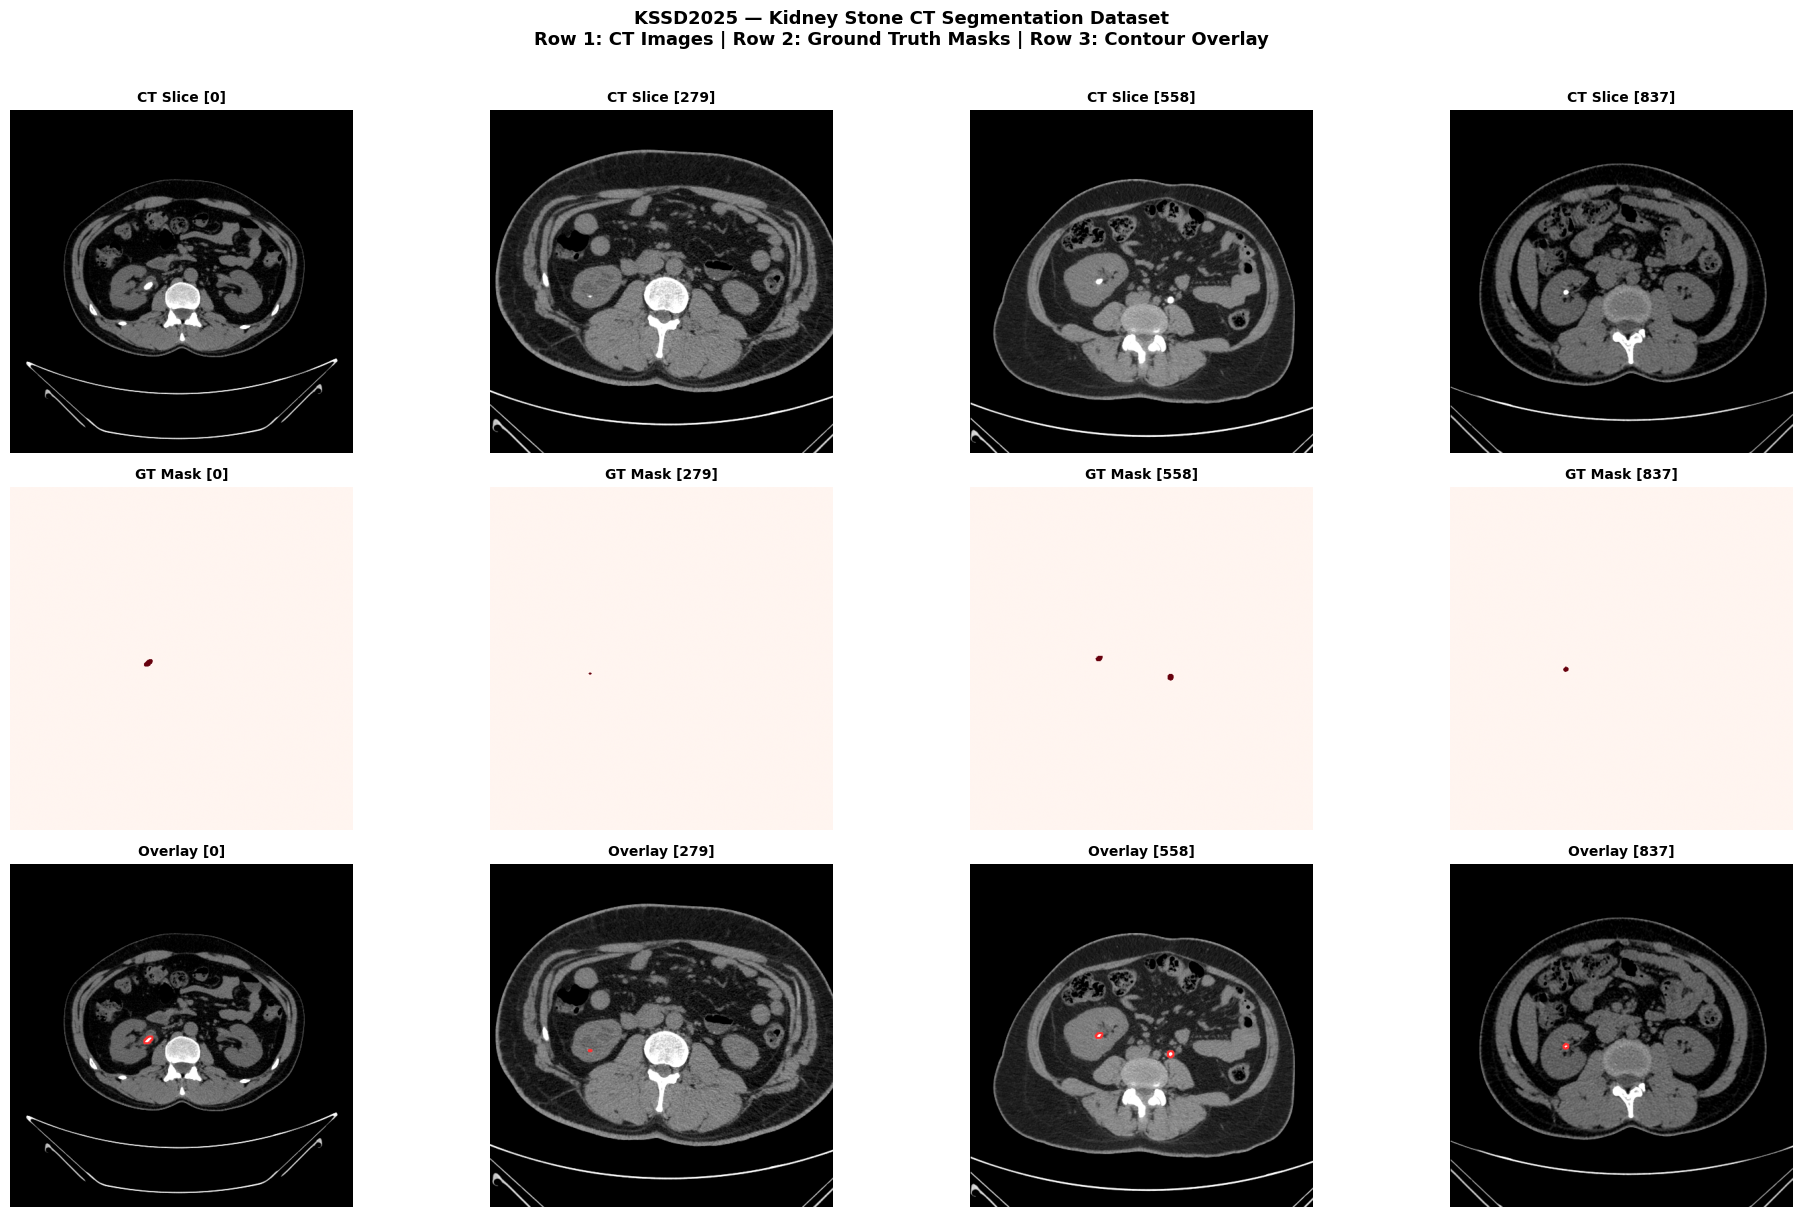

  ✅ Saved → /content/drive/MyDrive/nnunet_kidney/outputs/figures/fig1_dataset_visualization.png


In [12]:
print("=" * 70)
print("   DATASET VISUALIZATION ")
print("=" * 70)

N_SHOW = min(4, len(IMAGE_FILES))
indices = np.linspace(0, len(IMAGE_FILES)-1, N_SHOW, dtype=int)

fig = plt.figure(figsize=(5 * N_SHOW, 12))
fig.patch.set_facecolor("white")

for col, idx in enumerate(indices):
    img  = cv2.imread(str(IMAGE_FILES[idx]),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(MASK_FILES[idx]),   cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    mask_bin = (mask > 127).astype(np.uint8)

    # Row 1: Original CT
    ax1 = fig.add_subplot(3, N_SHOW, col + 1)
    ax1.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax1.set_title(f"CT Slice [{idx}]", fontsize=10, fontweight="bold")
    ax1.axis("off")

    # Row 2: Ground truth mask
    ax2 = fig.add_subplot(3, N_SHOW, N_SHOW + col + 1)
    ax2.imshow(mask_bin, cmap="Reds", vmin=0, vmax=1)
    ax2.set_title(f"GT Mask [{idx}]", fontsize=10, fontweight="bold")
    ax2.axis("off")

    # Row 3: Overlay
    ax3 = fig.add_subplot(3, N_SHOW, 2*N_SHOW + col + 1)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_rgb, contours, -1, (255, 50, 50), 2)
    ax3.imshow(img_rgb)
    ax3.set_title(f"Overlay [{idx}]", fontsize=10, fontweight="bold")
    ax3.axis("off")

plt.suptitle(
    "KSSD2025 — Kidney Stone CT Segmentation Dataset\n"
    "Row 1: CT Images | Row 2: Ground Truth Masks | Row 3: Contour Overlay",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()

fig_path = FIGS_DIR / "fig1_dataset_visualization.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"  ✅ Saved → {fig_path}")
print("=" * 70)



## 📋 Cell 7 — nnU-Net Directory Structure

Creates mandatory nnU-Net layout on Google Drive. Safe to re-run.

In [13]:
print("=" * 70)
print("     CREATING NNUNET DATASET DIRECTORY STRUCTURE")
print("=" * 70)

DATASET_DIR   = NNUNET_RAW / DATASET_NAME
IMAGES_TR_DIR = DATASET_DIR / "imagesTr"
LABELS_TR_DIR = DATASET_DIR / "labelsTr"
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"

for d in [IMAGES_TR_DIR, LABELS_TR_DIR, IMAGES_TS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  ✅ {d}")

print(f"\n  Dataset ID   : {DATASET_ID}")
print(f"  Dataset Name : {DATASET_NAME}")
print(f"  Trainer      : {TRAINER}")
print("=" * 70)



     CREATING NNUNET DATASET DIRECTORY STRUCTURE
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/imagesTr
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/labelsTr
  ✅ /content/drive/MyDrive/nnunet_kidney/nnUNet_raw/Dataset501_KidneyStone/imagesTs

  Dataset ID   : 501
  Dataset Name : Dataset501_KidneyStone
  Trainer      : nnUNetTrainer_250epochs


## 📋 Cell 8 — Convert Images to NIfTI Format

**Fixes applied:**
- Shape `(H, W, 1)` — correct for nnU-Net 2D (original was wrong `1,1,H,W`)
- `gc.collect()` every 50 images — prevents RAM OOM
- Skip if already converted — safe for re-runs after disconnect



In [14]:
existing = list(IMAGES_TR_DIR.glob("*.nii.gz"))
if len(existing) >= len(IMAGE_FILES):
    print(f"  ✅ {len(existing)} NIfTI images already on Drive — skipping.")
else:
    print("=" * 70)
    print("     CONVERTING IMAGES TO NIFTI  (H, W, 1) FORMAT")
    print("=" * 70)
    skipped = 0
    for i, fp in enumerate(tqdm(IMAGE_FILES, desc="  Images")):
        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if img is None:
            skipped += 1
            continue
        img_f  = img.astype(np.float32) / 255.0
        img_3d = img_f[:, :, np.newaxis]       # ✅ FIXED: (H, W, 1)
        nib.save(
            nib.Nifti1Image(img_3d, np.eye(4)),
            str(IMAGES_TR_DIR / f"KIDNEYSTONE_{i:03d}_0000.nii.gz")
        )
        if (i + 1) % 50 == 0:
            gc.collect()               # ✅ RAM flush every 50 images

    print(f"\n  ✅ Converted: {len(IMAGE_FILES) - skipped} | Skipped: {skipped}")
print("=" * 70)




     CONVERTING IMAGES TO NIFTI  (H, W, 1) FORMAT


  Images: 100%|██████████| 838/838 [00:43<00:00, 19.34it/s]


  ✅ Converted: 838 | Skipped: 0


CELL 9 ── Convert Masks to NIfT

In [15]:
existing_m = list(LABELS_TR_DIR.glob("*.nii.gz"))
if len(existing_m) >= len(MASK_FILES):
    print(f"  ✅ {len(existing_m)} NIfTI masks already on Drive — skipping.")
else:
    print("=" * 70)
    print("     CONVERTING MASKS TO NIFTI  (H, W, 1) FORMAT")
    print("=" * 70)
    skipped = 0
    for i, fp in enumerate(tqdm(MASK_FILES, desc="  Masks")):
        mask = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            skipped += 1
            continue
        mask_bin = (mask > 127).astype(np.uint8)
        mask_3d  = mask_bin[:, :, np.newaxis]  # ✅ FIXED: (H, W, 1)
        nib.save(
            nib.Nifti1Image(mask_3d, np.eye(4)),
            str(LABELS_TR_DIR / f"KIDNEYSTONE_{i:03d}.nii.gz")
        )
        if (i + 1) % 50 == 0:
            gc.collect()

    print(f"\n  ✅ Converted: {len(MASK_FILES) - skipped} | Skipped: {skipped}")
print("=" * 70)


# ════════════════════════════════════════════════════════════════════════════
# CELL 10 ── Dataset JSON + Integrity Check
# ════════════════════════════════════════════════════════════════════════════

     CONVERTING MASKS TO NIFTI  (H, W, 1) FORMAT


  Masks: 100%|██████████| 838/838 [00:21<00:00, 39.06it/s]


  ✅ Converted: 838 | Skipped: 0


In [16]:
# ── dataset.json ─────────────────────────────────────────────────────────────
json_path = DATASET_DIR / "dataset.json"
if not json_path.exists():
    n_tr = len(list(IMAGES_TR_DIR.glob("*.nii.gz")))
    dj   = {
        "channel_names"                 : {"0": "CT"},
        "labels"                        : {"background": 0, "kidney_stone": 1},
        "numTraining"                   : n_tr,
        "file_ending"                   : ".nii.gz",
        "overwrite_image_reader_writer" : "SimpleITKIO",
        "name"                          : "KidneyStone",
        "description"                   : "KSSD2025 Kidney Stone Segmentation — IEEE",
    }
    with open(json_path, "w") as f:
        json.dump(dj, f, indent=2)
    print(f"  ✅ dataset.json created — {n_tr} training samples")
else:
    print(f"  ✅ dataset.json exists — skipping")

# ── Integrity check ──────────────────────────────────────────────────────────
img_nii = sorted(IMAGES_TR_DIR.glob("KIDNEYSTONE_*_0000.nii.gz"))
lbl_nii = sorted(LABELS_TR_DIR.glob("KIDNEYSTONE_*.nii.gz"))
img_ids = {f.name.split("_0000")[0] for f in img_nii}
lbl_ids = {f.name.replace(".nii.gz","") for f in lbl_nii if "_0000" not in f.name}
miss    = (img_ids - lbl_ids) | (lbl_ids - img_ids)

print(f"\n  Images : {len(img_nii)}  |  Labels : {len(lbl_nii)}")
if miss:
    print(f"  ⚠  Mismatches found: {list(miss)[:5]}")
else:
    print(f"  ✅ All pairs matched — no mismatches")

if img_nii:
    s  = nib.load(str(img_nii[0]))
    sl = nib.load(str(LABELS_TR_DIR / img_nii[0].name.replace("_0000","")))
    print(f"  Image shape  : {s.shape}   (expect H×W×1)")
    print(f"  Label shape  : {sl.shape}  (expect H×W×1)")
    print(f"  Label values : {np.unique(sl.get_fdata())}  (expect [0. 1.])")

print("=" * 70)




  ✅ dataset.json created — 838 training samples

  Images : 838  |  Labels : 838
  ✅ All pairs matched — no mismatches
  Image shape  : (512, 512, 1)   (expect H×W×1)
  Label shape  : (512, 512, 1)  (expect H×W×1)
  Label values : [0. 1.]  (expect [0. 1.])


## 📋 Cell 11 — nnU-Net Planning & Preprocessing


In [17]:
print("=" * 70)
print("        NNUNET PLANNING AND PREPROCESSING")
print("=" * 70)

plans_path = NNUNET_PREP / DATASET_NAME / "nnUNetPlans.json"
if plans_path.exists():
    print(f"  ✅ Already preprocessed — {plans_path}")
    print("  Delete the folder to force reprocessing.")
else:
    cmd = [
        "nnUNetv2_plan_and_preprocess",
        "-d", str(DATASET_ID),
        "--verify_dataset_integrity",
        "-np", "2",
    ]
    print(f"  Command: {' '.join(cmd)}\n")
    r = subprocess.run(cmd, capture_output=True, text=True)
    out = r.stdout
    print(out[-4000:] if len(out) > 4000 else out)
    if r.stderr:
        print("  STDERR:", r.stderr[-400:])
    print(f"\n  {'✅' if r.returncode == 0 else '❌'} Return code: {r.returncode}")

print("=" * 70)




        NNUNET PLANNING AND PREPROCESSING
  Command: nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity -np 2

Fingerprint extraction...
Dataset501_KidneyStone
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 14, 'patch_size': (np.int64(512), np.int64(448)), 'median_image_size_in_voxels': array([512., 416.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['CTNormalizati

## 📋 Cell 12 — Auto-Configured Architecture Parameters

 **Methods → Network Architecture** section.

In [18]:
print("=" * 70)
print("       AUTO-CONFIGURED NETWORK ARCHITECTURE")
print("=" * 70)

if plans_path.exists():
    with open(plans_path) as f:
        plans = json.load(f)

    arch_params = {}
    for cfg_name, cfg in plans.get("configurations", {}).items():
        arch_params[cfg_name] = {}
        print(f"\n  ── Configuration: {cfg_name} ──────────────────────────")
        keys = ["patch_size", "batch_size", "num_pool_per_axis",
                "UNet_base_num_features", "n_conv_per_stage_encoder",
                "n_conv_per_stage_decoder", "normalization_schemes",
                "resampling_fn_data", "spacing"]
        for k in keys:
            if k in cfg:
                print(f"    {k:<42} : {cfg[k]}")
                arch_params[cfg_name][k] = cfg[k]

    # Save for paper
    with open(TABLES_DIR / "architecture_params.json", "w") as f:
        json.dump(arch_params, f, indent=2)

    print(f"\n  ── IEEE Methods → Network Architecture ──────────────────")
    ps = arch_params.get("2d", arch_params.get(list(arch_params.keys())[0], {}))
    print(f"""
  'The network architecture was automatically determined by nnU-Net v2's
   self-configuring framework through dataset fingerprint analysis [REF].
   For the 2D configuration on KSSD2025, nnU-Net selected a patch size
   of {ps.get('patch_size','auto')}, batch size of {ps.get('batch_size','auto')},
   and encoder with {ps.get('n_conv_per_stage_encoder','auto')} convolutions
   per stage. Feature maps start at {ps.get('UNet_base_num_features','auto')}
   channels and double at each downsampling stage.'
  """)
else:
    print("  ⚠  Run Cell 11 first.")

print("=" * 70)




       AUTO-CONFIGURED NETWORK ARCHITECTURE

  ── Configuration: 2d ──────────────────────────
    patch_size                                 : [512, 448]
    batch_size                                 : 14
    normalization_schemes                      : ['CTNormalization']
    resampling_fn_data                         : resample_data_or_seg_to_shape
    spacing                                    : [1.0, 1.0]

  ── IEEE Methods → Network Architecture ──────────────────

  'The network architecture was automatically determined by nnU-Net v2's
   self-configuring framework through dataset fingerprint analysis [REF].
   For the 2D configuration on KSSD2025, nnU-Net selected a patch size
   of [512, 448], batch size of 14,
   and encoder with auto convolutions
   per stage. Feature maps start at auto
   channels and double at each downsampling stage.'
  


## 📋 Cell 13 — Analysis Functions

Defines ALL analysis functions used after training.


In [28]:
# ── Training log parser ──────────────────────────────────────────────────────
def parse_training_log(fold_dir: Path):
    """Parse nnU-Net training_log.txt → per-epoch metrics dict."""
    log_path  = fold_dir / "training_log.txt"
    prog_path = fold_dir / "progress.json"

    if log_path.exists():
        epochs, tr_loss, vl_loss, pseudo_dice, lr_vals = [], [], [], [], []
        ep_pat = re.compile(r"Epoch\s+(\d+)")
        tl_pat = re.compile(r"train loss\s*:\s*([-\d.eE+]+)")
        vl_pat = re.compile(r"val loss\s*:\s*([-\d.eE+]+)")
        pd_pat = re.compile(r"Pseudo dice\s*\[([^\]]+)\]")
        lr_pat = re.compile(r"lr\s*:\s*([\d.eE+\-]+)")
        cur_ep = None
        with open(log_path) as f:
            for line in f:
                em = ep_pat.search(line)
                if em:
                    cur_ep = int(em.group(1))
                tm = tl_pat.search(line)
                if tm and cur_ep is not None:
                    tr_loss.append(float(tm.group(1)))
                    epochs.append(cur_ep)
                vm = vl_pat.search(line)
                if vm:
                    vl_loss.append(float(vm.group(1)))
                dm = pd_pat.search(line)
                if dm:
                    vals = [float(x.strip()) for x in dm.group(1).split(",")]
                    pseudo_dice.append(float(np.mean(vals)))
                lm = lr_pat.search(line)
                if lm:
                    lr_vals.append(float(lm.group(1)))
        n = min(len(epochs), len(tr_loss))
        return {
            "epochs"      : epochs[:n],
            "train_loss"  : tr_loss[:n],
            "val_loss"    : vl_loss[:n]    if vl_loss    else [0]*n,
            "pseudo_dice" : pseudo_dice[:n] if pseudo_dice else [0]*n,
            "lr"          : lr_vals[:n]    if lr_vals    else [0]*n,
        }

    if prog_path.exists():
        with open(prog_path) as f:
            data = json.load(f)
        n = len(data.get("train_losses", []))
        return {
            "epochs"      : list(range(n)),
            "train_loss"  : data.get("train_losses",          [0]*n),
            "val_loss"    : data.get("val_losses",             [0]*n),
            "pseudo_dice" : data.get("val_eval_criterion_MA",  [0]*n),
            "lr"          : data.get("lrs",                    [0]*n),
        }
    return None


# ── Convergence detection ────────────────────────────────────────────────────
def detect_convergence(pseudo_dice, window=15, min_delta=0.0005, patience=20):
    """Savitzky-Golay plateau detection. Returns (epoch, smoothed, improvements)."""
    if len(pseudo_dice) < window + 2:
        return len(pseudo_dice), np.array(pseudo_dice), np.zeros(len(pseudo_dice))
    w        = (window | 1)                        # ensure odd
    w        = max(5, min(w, len(pseudo_dice) - 2))
    smoothed = savgol_filter(pseudo_dice, window_length=w, polyorder=2)
    impr     = np.diff(smoothed, prepend=smoothed[0])
    conv, c  = len(pseudo_dice), 0
    for i, d in enumerate(impr):
        if d < min_delta:
            c += 1
            if c >= patience:
                conv = max(0, i - patience + 1)
                break
        else:
            c = 0
    return conv, smoothed, impr


# ── Read fold Dice from summary ──────────────────────────────────────────────
def read_fold_summary(fold_num):
    """Read complete metrics from nnU-Net validation summary.json."""
    fold_dir  = NNUNET_RES / DATASET_NAME / TRAINER / f"fold_{fold_num}"
    vs        = fold_dir / "validation" / "summary.json"
    if not vs.exists():
        return None, fold_dir
    with open(vs) as f:
        summary = json.load(f)
    result = {"dice":[], "precision":[], "recall":[], "hd95":[], "iou":[]}
    for case in summary.get("metric_per_case", []):
        m = case.get("metrics", {}).get("1", {})
        if not m:
            continue
        d   = m.get("Dice", 0.0)
        tp  = m.get("TP",  None)
        fp  = m.get("FP",  None)
        fn  = m.get("FN",  None)
        tn  = m.get("TN",  None)
        result["dice"].append(d)
        result["precision"].append(m.get("Precision", d))
        result["recall"].append(m.get("Recall",    d))
        hd = m.get("HD95", None)
        if hd and not (np.isnan(hd) or np.isinf(hd)):
            result["hd95"].append(hd)
        if tp is not None and fp is not None and fn is not None:
            denom = tp + fp + fn
            result["iou"].append(tp/(denom+1e-8))
        else:
            result["iou"].append(d/(2.0 - d + 1e-8))
    return result, fold_dir


# ── Timing ───────────────────────────────────────────────────────────────────
TIMING_PATH    = OUTPUTS_DIR / "training_timing.json"
TRAINING_TIMES = {}
if TIMING_PATH.exists():
    with open(TIMING_PATH) as f:
        TRAINING_TIMES = json.load(f)
    print("  ✅ Loaded existing timing data:")
    for k, v in TRAINING_TIMES.items():
        print(f"    {k}: {v['elapsed_hm']}  GPU:{v['gpu']}")


def train_fold(fold_num):
    """
    Train one fold with:
    - GPU memory clear before/after (OOM prevention)
    - Wall-clock timing
    - No --npz flag (removed: was causing RAM/Drive overflow)
    - Live output streaming
    """
    clear_gpu()
    gpu_report(f"fold_{fold_num} START")

    cmd = [
        "nnUNetv2_train", str(DATASET_ID),
        CONFIG, str(fold_num),
        "-tr", TRAINER,
        # ✅ --npz REMOVED — caused RAM overflow with 838 samples
    ]
    print(f"\n  Command: {' '.join(cmd)}\n")
    t0 = time.time()

    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()

    elapsed = time.time() - t0
    h, m    = int(elapsed//3600), int((elapsed%3600)//60)
    rc      = proc.returncode
    gname   = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    clear_gpu()
    gpu_report(f"fold_{fold_num} END")

    entry = {
        "fold": fold_num, "elapsed_sec": round(elapsed,1),
        "elapsed_hm": f"{h}h {m}m", "return_code": rc, "gpu": gname,
    }
    TRAINING_TIMES[f"fold_{fold_num}"] = entry
    with open(TIMING_PATH, "w") as f:
        json.dump(TRAINING_TIMES, f, indent=2)

    print(f"\n  {'✅' if rc==0 else '❌'} Fold {fold_num} — {h}h {m}m | rc={rc}")
    return entry


def fold_convergence_report(fold_num):
    """Run convergence analysis and print IEEE methods text for one fold."""
    fold_dir = NNUNET_RES / DATASET_NAME / TRAINER / f"fold_{fold_num}"
    ld       = parse_training_log(fold_dir)
    if not ld or not ld["epochs"] or not any(v != 0 for v in ld["pseudo_dice"]):
        print(f"  ⚠  No log for Fold {fold_num}: {fold_dir/'training_log.txt'}")
        return

    dv              = ld["pseudo_dice"]
    ce, sm, _       = detect_convergence(dv)
    ep              = ld["epochs"]

    print(f"\n  Fold {fold_num} — Epochs: {max(ep)} | "
          f"Conv. epoch: {ce} | Best Dice: {max(dv):.4f}")

    plot_single_convergence(ld, fold_num, ce, sm)

    res, _ = read_fold_summary(fold_num)
    if res and res["dice"]:
        print(f"  Validation Dice  : {np.mean(res['dice']):.4f} ± {np.std(res['dice']):.4f}")
        print(f"  Validation HD95  : "
              f"{np.mean(res['hd95']):.3f} mm" if res["hd95"] else "  HD95: N/A")


def plot_single_convergence(ld, fold_num, ce, sm):
    """Plot convergence for one fold and save to Drive."""
    ep  = ld["epochs"]
    tl  = ld["train_loss"]
    dv  = ld["pseudo_dice"]

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    fig.patch.set_facecolor("white")

    ax1.plot(ep, tl, color="#1565C0", alpha=0.5, lw=1.2, label="Train Loss")
    ax2.plot(ep[:len(dv)], dv, color="#81C784", alpha=0.3, lw=1.0, label="Dice (raw)")
    ax2.plot(ep[:len(sm)], sm, color="#2E7D32", lw=2.5, label="Dice (smoothed)")

    if ce < max(ep):
        ax2.axvline(x=ce, color="#FF6F00", ls="--", lw=2.0)
        ax2.annotate(f"Conv. Ep.{ce}",
                     xy=(ce, max(sm)*0.97), xytext=(ce + max(ep)*0.05, max(sm)*0.91),
                     fontsize=10, color="#E65100", fontweight="bold",
                     arrowprops=dict(arrowstyle="->", color="#E65100"))

    ax2.axhline(y=PAPER_DICE, color="#9C27B0", ls=":", lw=1.8,
                label=f"Paper baseline ({PAPER_DICE:.4f})")

    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12, color="#1565C0")
    ax2.set_ylabel("Pseudo Dice", fontsize=12, color="#2E7D32")
    ax1.tick_params(axis="y", labelcolor="#1565C0")
    ax2.tick_params(axis="y", labelcolor="#2E7D32")
    plt.title(f"nnU-Net Convergence — Fold {fold_num} | KSSD2025",
              fontsize=12, fontweight="bold")
    handles  = [mpatches.Patch(color="#1565C0", label="Train Loss"),
                mpatches.Patch(color="#2E7D32", label="Dice (smoothed)"),
                mpatches.Patch(color="#FF6F00", label=f"Conv. Epoch≈{ce}"),
                mpatches.Patch(color="#9C27B0", label=f"Paper ({PAPER_DICE:.4f})")]
    ax1.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.85)
    ax1.grid(True, alpha=0.3, ls="--")
    plt.tight_layout()
    sp = FIGS_DIR / f"convergence_fold_{fold_num}.png"
    plt.savefig(sp, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  ✅ Saved → {sp}")


print("  ✅ All analysis functions loaded:")
print("    train_fold(n) | fold_convergence_report(n)")
print("    parse_training_log | detect_convergence")
print("    read_fold_summary  | plot_single_convergence")
print("=" * 70)



  ✅ Loaded existing timing data:
    fold_0: 0h 0m  GPU:NVIDIA A100-SXM4-40GB
  ✅ All analysis functions loaded:
    train_fold(n) | fold_convergence_report(n)
    parse_training_log | detect_convergence
    read_fold_summary  | plot_single_convergence


## 📋 Cell 14 — Train Fold 0  (1 of 5)



In [ ]:
print("=" * 70)
print("  TRAINING FOLD 0  (1/5)")
print("=" * 70)
train_fold(0)

  TRAINING FOLD 0  (1/5)
  GPU [fold_0 START        ] Free:42.4GB / 42.4GB  [████████████████████]

  Command: nnUNetv2_train 501 2d 0 -tr nnUNetTrainer_250epochs


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-03-08 20:34:00.579414: do_dummy_2d_data_aug: False
2026-03-08 20:34:00.613941: Using splits from existing split file: /content/